# Fashion Trend Forecasting - Data and Hypothesis

**Research question:** Can the first 8 weeks of a season's popularity data predict that style's seasonal peak? Does adding early review ratings improve accuracy further?

**Why it matters:** Fashion retailers commit to inventory months before a season begins. A model that forecasts peak demand from the first few weeks of early-season data could reduce overstock, cut markdowns, and improve sell-through rates. Even a modest MAE improvement of 1 - 2 popularity points translates to better stock decisions across thousands of SKUs.

**Data design:** Each style has a hidden annual buzz factor (mid-season boost) that elevates both peak popularity and early review ratings, creating a genuine independent signal in reviews that the trend line alone cannot see.

## Why Ridge, and not something fancier?

With only 48 instances, the smart choice isn't the most powerful model -
it's the one that won't overfit.

- ARIMA / Prophet watch a single signal, so they can't blend in the
  review data - and they want years of history I don't have.
- XGBoost / LightGBM are data-hungry; on 48 rows they'd just memorise
  noise. My Random Forest (Model C) already covers that check with less risk.
- LSTM / Transformer need far more data - a non-starter here.

So a Ridge regression is conditioned on style identity and is regularised
against overfitting - interpretable, stable, and quick to validate. The
Random Forest rides along as a second opinion.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

SEED    = 42
N_YEARS = 6
PERIOD  = 52          # weeks per year
N_WEEKS = N_YEARS * PERIOD   # 312

DATA_DIR    = Path('data')
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

rng = np.random.default_rng(SEED)

## Why synthetic data?

We use fully synthetic and completely deterministic data (seed = 42). This has a concrete reason: we know exactly what the true peak popularity value is for every style and every year - meaning we can honestly verify whether the models capture something real, not just noise.

In a real-world project the next step would be replacing the synthetic CSV files with real data (Google Trends + product reviews) without changing any code.

In [2]:
STYLES = {
    'oversized blazer': {'base': 40, 'slope':  0.060, 'amp':  8, 'peak_week':  8, 'fad': (120, 14, 16), 'noise': 3},
    'wide-leg jeans':   {'base': 33, 'slope':  0.110, 'amp':  6, 'peak_week':  2, 'fad': None,          'noise': 3},
    'cargo pants':      {'base': 30, 'slope':  0.045, 'amp':  5, 'peak_week':  4, 'fad': (150,  9, 26), 'noise': 4},
    'ballet flats':     {'base': 45, 'slope':  0.030, 'amp':  7, 'peak_week': 14, 'fad': None,          'noise': 3},
    'puffer jacket':    {'base': 50, 'slope':  0.000, 'amp': 30, 'peak_week': 50, 'fad': None,          'noise': 3},
    'slip dress':       {'base': 42, 'slope': -0.020, 'amp': 22, 'peak_week': 26, 'fad': None,          'noise': 3},
    'trench coat':      {'base': 48, 'slope': -0.050, 'amp': 12, 'peak_week': 40, 'fad': None,          'noise': 3},
    'chunky sneakers':  {'base': 56, 'slope': -0.080, 'amp':  5, 'peak_week':  1, 'fad': None,          'noise': 4},
}
STYLE_NAMES = list(STYLES.keys())

Hidden annual buzz factor - peaks at week 26 of each year.
Detectable in early review ratings, but NOT in the first 8 weeks of the trend line.

In [3]:
BUZZ_STD    = 10.0
buzz_matrix = rng.normal(0, BUZZ_STD, size=(len(STYLES), N_YEARS))  # shape (8, 6)

## Style design

The eight styles form four archetypes:
-  Rising - wide-leg jeans, blazer, cargo -  Slope is > 0 
- Stable - puffer jacket - Slope is around ≈ 0 
- Fading - trench coat, chunky sneakers - Slope is  < 0 
- Viral spike - cargo pants, blazer - fad Gaussian 

The Buzz factor is a hidden annual variable (± ~10 pts) that amplifies or reduces the mid-season peak. Early buyers sense it and leave better/worse reviews - but the trend line in weeks 1-8 does not yet show it, because the buzz peak is centred around week 26.

In [4]:
def generate_style_series(params, buzz_yrs):
    """Generate 312-week popularity series. Buzz peaks at week 26 of each year."""
    t      = np.arange(N_WEEKS)
    trend  = params['base'] + params['slope'] * t
    season = params['amp'] * np.cos(2 * np.pi * (t - params['peak_week']) / PERIOD)
    fad    = np.zeros(N_WEEKS)
    if params['fad']:
        c, w, h = params['fad']
        fad = h * np.exp(-((t - c)**2) / (2 * w**2))
    buzz = np.zeros(N_WEEKS)
    for y in range(N_YEARS):
        center = y * PERIOD + 25           # week 26 (0-indexed: 25)
        buzz  += buzz_yrs[y] * np.exp(-((t - center)**2) / (2 * 6**2))
    noise = rng.normal(0, params['noise'], size=N_WEEKS)
    return np.clip(trend + season + fad + buzz + noise, 0, 100)

dates      = pd.date_range('2021-01-03', periods=N_WEEKS, freq='W')
all_series = {}
rows       = {'date': dates}
for i, (style, params) in enumerate(STYLES.items()):
    s = generate_style_series(params, buzz_matrix[i])
    all_series[style] = s
    rows[style] = s

style_trends = pd.DataFrame(rows)
style_trends['year']         = style_trends.index // PERIOD
style_trends['week_in_year'] = style_trends.index % PERIOD + 1
style_trends.to_csv(DATA_DIR / 'trends_synthetic.csv', index=False)
print(f'trends_synthetic.csv written — {style_trends.shape}')
style_trends.head()

trends_synthetic.csv written — (312, 11)


,date,oversized blazer,wide-leg jeans,cargo pants,ballet flats,puffer jacket,slip dress,trench coat,chunky sneakers,year,week_in_year
0,2021-01-03,46.581776,38.368300,31.571893,45.280895,74.400669,19.350584,46.165035,55.814784,0,1
1,2021-01-10,45.568741,40.216864,29.452982,46.928891,76.064800,18.996186,51.030335,67.249085,0,2
2,2021-01-17,46.977408,42.220297,38.288366,41.696610,73.088527,21.477738,40.688312,57.105337,0,3
3,2021-01-24,48.661404,36.112184,36.496742,47.768905,71.788306,20.638303,48.363814,56.430921,0,4
4,2021-01-31,42.958846,38.893420,44.711854,46.713591,72.606398,22.359080,43.376942,60.184128,0,5


## Generative model

$$\text{popularity}(t) = \underbrace{b_s + m_s t}_{\text{trend}} + \underbrace{A_s \cos\!\left(\frac{2\pi(t - \phi_s)}{52}\right)}_{\text{seasonality}} + \underbrace{h_s e^{-(t-c_s)^2/2w_s^2}}_{\text{viral fad}} + \underbrace{B_y e^{-(t-26_y)^2/72}}_{\text{buzz}} + \underbrace{\varepsilon_t}_{\text{noise}}$$

Key point: the buzz component $B_y$ is hidden from the trend line in weeks 1–8 (it is centred around week 26), but it is felt by early buyers and echoes in their reviews. If the model can "hear" the buzz from reviews before week 9 - it should outperform the baseline.

Ground-truth: actual peak VALUE = max popularity per season (includes buzz effect)

In [5]:
records = []
for i, style in enumerate(STYLE_NAMES):
    for y in range(N_YEARS):
        season_vals = all_series[style][y * PERIOD:(y + 1) * PERIOD]
        records.append({'style': style, 'year': y,
                         'buzz':              round(float(buzz_matrix[i, y]), 2),
                         'actual_peak_value': float(np.max(season_vals))})

truth = pd.DataFrame(records)
truth.to_csv(RESULTS_DIR / 'peak_ground_truth.csv', index=False)

pivot = truth.pivot(index='style', columns='year', values='actual_peak_value').round(1)
pivot.columns = [f'Y{c+1}' for c in pivot.columns]
print('Ground-truth peak popularity values per style x year:')
print(pivot.to_string())

Ground-truth peak popularity values per style x year:
                    Y1    Y2    Y3    Y4    Y5    Y6
style                                               
ballet flats      59.4  60.7  58.6  59.0  69.3  65.2
cargo pants       44.7  47.6  69.5  67.1  50.1  53.0
chunky sneakers   67.2  65.6  63.7  53.0  53.8  48.7
oversized blazer  53.1  55.9  75.9  65.6  63.4  68.1
puffer jacket     86.7  83.6  83.6  84.0  79.5  83.9
slip dress        86.8  60.9  60.2  55.1  68.0  68.9
trench coat       59.3  60.1  56.2  53.0  56.5  48.9
wide-leg jeans    44.6  49.4  57.6  62.7  71.5  74.8


## Target variable

We predict the maximum popularity a style reaches within its annual season (weeks 1–52). Because styles carry a positive or negative slope, this value changes meaningfully year over year - rising styles reach progressively higher peaks, fading styles progressively lower ones.

The buzz factor adds additional random variation (± ~10 pts), independent of the long-term trend. It is the only thing reviews know that the trend line (in the first 8 weeks) does not.

In [6]:
# Review generator: ~40 reviews per style x year, week-stamped.
N_REVIEWS    = 40
BUZZ_SIGNAL  = 0.12
rev_rng      = np.random.default_rng(SEED + 1)
rev_rows     = []

for i, style in enumerate(STYLE_NAMES):
    series = all_series[style]
    for y in range(N_YEARS):
        pop   = series[y * PERIOD:(y + 1) * PERIOD]
        probs = pop / pop.sum()
        weeks = rev_rng.choice(PERIOD, size=N_REVIEWS, p=probs) + 1
        bz    = float(buzz_matrix[i, y])
        for wk in weeks:
            pop_val     = series[y * PERIOD + wk - 1]
            base_rating = 2.5 + (pop_val / 100) * 2.5 + bz * BUZZ_SIGNAL
            # Rating = f(popularity) + buzz_signal
            rating      = float(np.clip(round(rev_rng.normal(base_rating, 0.5)), 1, 5))
            rev_rows.append({'style': style, 'year': y,
                              'week_in_year': int(wk), 'rating': rating})

reviews = pd.DataFrame(rev_rows)
reviews.to_csv(DATA_DIR / 'reviews_synthetic.csv', index=False)
print(f'reviews_synthetic.csv written {reviews.shape}')
reviews.head()

reviews_synthetic.csv written (1920, 4)


,style,year,week_in_year,rating
0,oversized blazer,0,33,4.0
1,oversized blazer,0,3,4.0
2,oversized blazer,0,1,4.0
3,oversized blazer,0,44,3.0
4,oversized blazer,0,29,3.0


## Review signal

Reviews are distributed proportionally to popularity - more come when the style is popular. The rating is determined by:

$$\text{base\_rating} = 2.5 + \frac{\text{popularity}}{100} \times 2.5 + B_y \times 0.12$$

The buzz term ($B_y \times 0.12$) is small in amplitude but systematic: if buzz is +10, early reviews will average ~1.2 points higher. Whether the model can detect this systematic shift from a small number of early reviews (typically 4–6 per style over 8 weeks) we can reveal later.

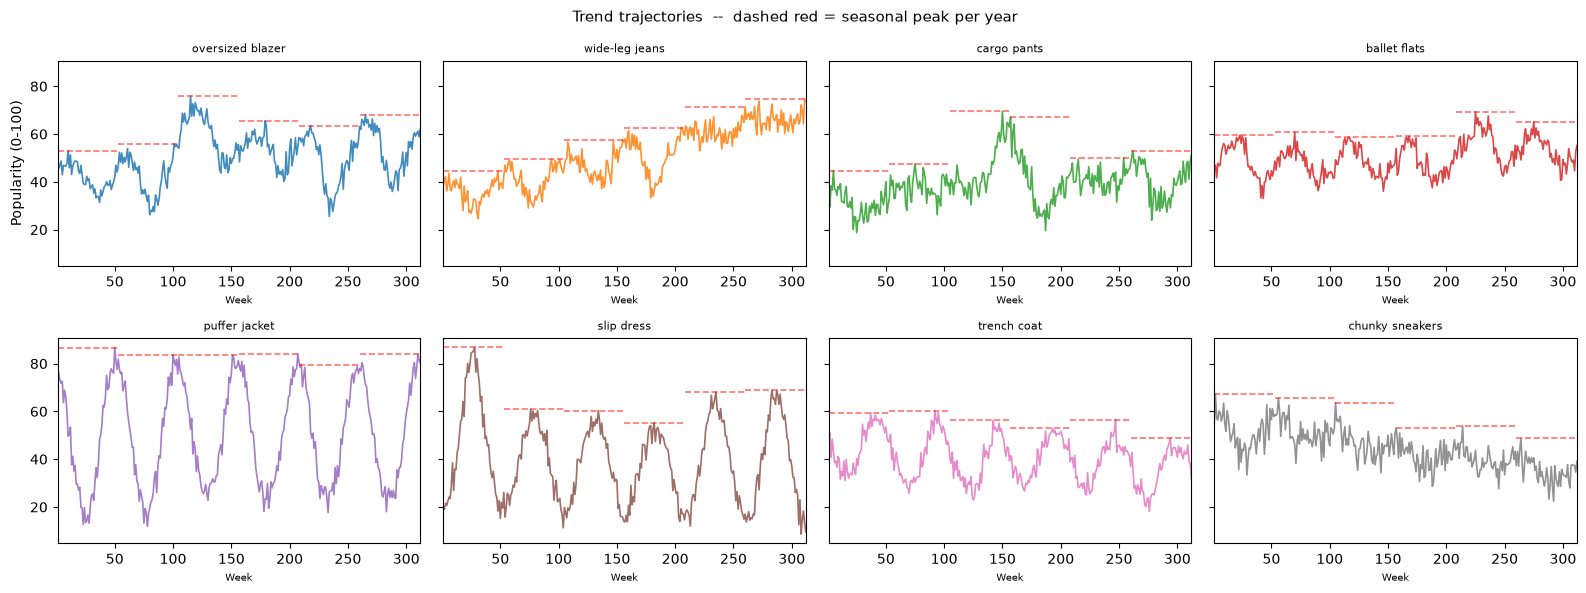

In [7]:
# Plot 1: Trend trajectories with annual peak-value markers
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey=True)
axes   = axes.flatten()
colors = plt.cm.tab10.colors

for i, style in enumerate(STYLE_NAMES):
    ax  = axes[i]
    ser = all_series[style]
    ax.plot(np.arange(1, N_WEEKS + 1), ser, color=colors[i], linewidth=1.2, alpha=0.85)
    for y in range(N_YEARS):
        pv = truth.loc[
            (truth['style'] == style) & (truth['year'] == y), 'actual_peak_value'
        ].values[0]
        ax.axhline(pv, xmin=y / N_YEARS, xmax=(y + 1) / N_YEARS,
                   color='red', linewidth=1.2, linestyle='--', alpha=0.55)
    ax.set_title(style, fontsize=8)
    ax.set_xlim(1, N_WEEKS)
    ax.set_xlabel('Week', fontsize=7)

axes[0].set_ylabel('Popularity (0-100)')
fig.suptitle('Trend trajectories  --  dashed red = seasonal peak per year', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_trends.png', dpi=100)
plt.show()

The four archetypes are clearly visible. For rising styles (wide-leg jeans, blazer) the red dashed lines climb each year - the peak grows. For fading styles (chunky sneakers, trench coat) - it drops.

The interesting part is the vertical distance between dashed lines in adjacent years: it reflects the combination of the slope effect and the buzz factor. This is exactly the variation we predict in the following notebooks.

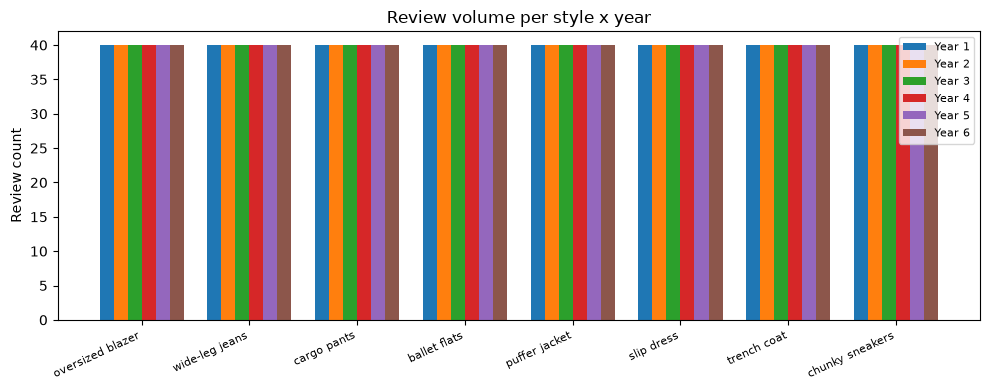

In [8]:
# Plot 2: Review volume per style x year
vol     = reviews.groupby(['style', 'year']).size().reset_index(name='count')
vol_piv = vol.pivot(index='style', columns='year', values='count').fillna(0)

fig, ax = plt.subplots(figsize=(10, 4))
x, w = np.arange(len(STYLE_NAMES)), 0.13
for y in range(N_YEARS):
    counts = [vol_piv.loc[s, y] if s in vol_piv.index else 0 for s in STYLE_NAMES]
    ax.bar(x + y * w, counts, w, label=f'Year {y+1}')
ax.set_xticks(x + w * 2.5)
ax.set_xticklabels(STYLE_NAMES, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Review count')
ax.set_title('Review volume per style x year')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'fig_review_vol.png', dpi=100)
plt.show()

## Review volume

Review volume follows popularity. Styles with a higher baseline (puffer jacket: base=50) receive more reviews. Important: the year-over-year difference for the same style is small - only 4 - 6 reviews fall in the early window (weeks 1-8). This is why the mean rating of those few reviews is a noisy signal - but one systematically shifted by the buzz factor.